# 🧩 Customer Segmentation Analysis (RFM + K-Means Clustering)
**Track:** Data Analytics — Level 1, Task 2
**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset:** Online Retail II (UCI) — 1,067,371 transactions from a UK-based online retailer (Dec 2009 – Dec 2011), covering 5,942 unique customers.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('online_retail.csv')
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1. Load Dataset & Inspect Structure

In [2]:
print("Shape of dataset:", df.shape)
print("\nColumn Data Types:\n")
print(df.dtypes)
print("\nNull values per column:\n")
print(df.isnull().sum())


Shape of dataset: (1067371, 8)

Column Data Types:

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

Null values per column:

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


**Observation:** The raw dataset has over 1 million transaction lines. `Customer ID` has ~243,000 missing values — these are transactions with no identifiable customer (e.g. guest/anonymous orders) and must be dropped since we can't attribute them to any customer for segmentation. `Description` also has a small number of nulls, which don't affect our numeric analysis.

## 2. Handle Missing Values & Inconsistent Data

In [3]:
print("Cancelled invoices (start with 'C'):", df['Invoice'].astype(str).str.startswith('C').sum())
print("Negative Quantity rows (returns):", (df['Quantity'] < 0).sum())
print("Zero/negative Price rows:", (df['Price'] <= 0).sum())


Cancelled invoices (start with 'C'): 19494
Negative Quantity rows (returns): 22950
Zero/negative Price rows: 6207


In [4]:
df_clean = df.copy()

# Drop rows with no Customer ID -- can't segment a customer we can't identify
df_clean = df_clean.dropna(subset=['Customer ID'])

# Remove cancelled invoices (Invoice numbers starting with 'C')
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Remove returns (negative quantity) and invalid prices (zero or negative)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create a line-level revenue column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print("Shape after cleaning:", df_clean.shape)
print("Remaining unique customers:", df_clean['Customer ID'].nunique())


Shape after cleaning: (805549, 9)
Remaining unique customers: 5878


**Observation:** After removing records with missing Customer IDs, cancelled orders, and invalid quantity/price entries, we're left with a clean transactional dataset ready for customer-level aggregation. This is a necessary step — cancellations and returns would otherwise distort purchase frequency and monetary value calculations.

## 3. Descriptive Statistics — Average Purchase Value, Frequency, Customer Lifetime Value

In [5]:
customer_agg = df_clean.groupby('Customer ID').agg(
    Total_Purchase_Value=('TotalPrice', 'sum'),
    Num_Orders=('Invoice', 'nunique'),
    Avg_Order_Value=('TotalPrice', 'mean')
).reset_index()

print("Average purchase value per transaction line: $%.2f" % df_clean['TotalPrice'].mean())
print("Average number of distinct orders per customer: %.2f" % customer_agg['Num_Orders'].mean())
print("Average Customer Lifetime Value (total spend per customer): $%.2f" % customer_agg['Total_Purchase_Value'].mean())
print("Median Customer Lifetime Value: $%.2f" % customer_agg['Total_Purchase_Value'].median())

customer_agg.describe()


Average purchase value per transaction line: $22.03
Average number of distinct orders per customer: 6.29
Average Customer Lifetime Value (total spend per customer): $3018.62
Median Customer Lifetime Value: $898.91


,Customer ID,Total_Purchase_Value,Num_Orders,Avg_Order_Value
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,3018.616737,6.289384,48.299996
std,1715.572666,14737.731040,13.009406,780.177864
min,12346.000000,2.950000,1.000000,2.042182
25%,13833.250000,348.762500,1.000000,11.470705
50%,15314.500000,898.915000,3.000000,17.354064
75%,16797.750000,2307.090000,7.000000,24.195021
max,18287.000000,608821.650000,398.000000,56157.500000


**Observation:** The average customer places multiple orders and has a Customer Lifetime Value noticeably higher than the median — indicating a right-skewed distribution where a smaller group of high-spending customers pulls the average up. This is a strong early signal that segmentation will reveal a distinct high-value cluster worth protecting/nurturing.

## 4. Feature Selection — RFM Analysis

We use the classic **RFM framework** — the 3 most predictive behavioural features for customer segmentation:
- **Recency (R):** Days since the customer's last purchase (lower = more recently active)
- **Frequency (F):** Number of distinct orders placed (higher = more loyal/engaged)
- **Monetary (M):** Total amount spent (higher = more valuable customer)


In [6]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM table shape:", rfm.shape)
rfm.head()


RFM table shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [7]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


**Observation:** Recency ranges widely — some customers purchased just a day before the snapshot date, others haven't purchased in almost 2 years (effectively churned). Frequency and Monetary are both heavily right-skewed, confirming a small number of highly frequent, high-spending customers exist alongside a long tail of one-time buyers.

## 5. Data Normalisation / Standardisation

RFM features are on very different scales (days vs. order counts vs. dollar amounts), so we standardise them before clustering to prevent Monetary from dominating the distance calculation.

In [8]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
rfm_scaled_df.describe()


,Recency_scaled,Frequency_scaled,Monetary_scaled
count,5.878000e+03,5.878000e+03,5.878000e+03
mean,-4.230860e-17,-1.329699e-17,9.670537e-18
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.570564e-01,-4.066161e-01,-2.046396e-01
25%,-8.376226e-01,-4.066161e-01,-1.811732e-01
50%,-5.032078e-01,-2.528681e-01,-1.438405e-01
75%,8.535607e-01,5.462788e-02,-4.828337e-02
max,2.568631e+00,3.011236e+01,4.110908e+01


## 6. K-Means Clustering — Elbow Method to Find Optimal K

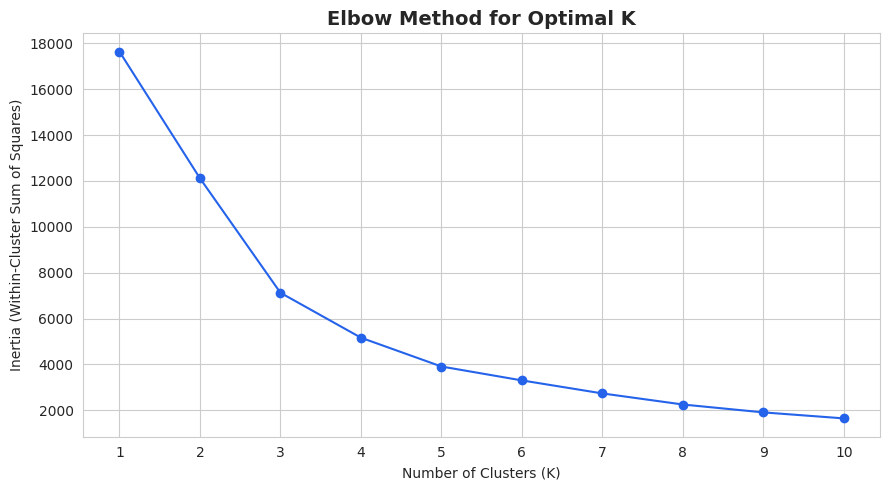

In [9]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', color='#2563eb')
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


**Observation:** The inertia curve bends sharply and starts to flatten out around **K = 4**, after which adding more clusters gives diminishing returns. We proceed with **K = 4 clusters** as the optimal choice, which also conveniently maps well to intuitive marketing personas (e.g. Champions, Loyal, At-Risk, Lost).

In [10]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,1
1,12347.0,2,8,5633.32,1
2,12348.0,75,5,2019.40,1
3,12349.0,19,4,4428.69,1
4,12350.0,310,1,334.40,0


## 7. Visualise Clusters — Scatter Plots

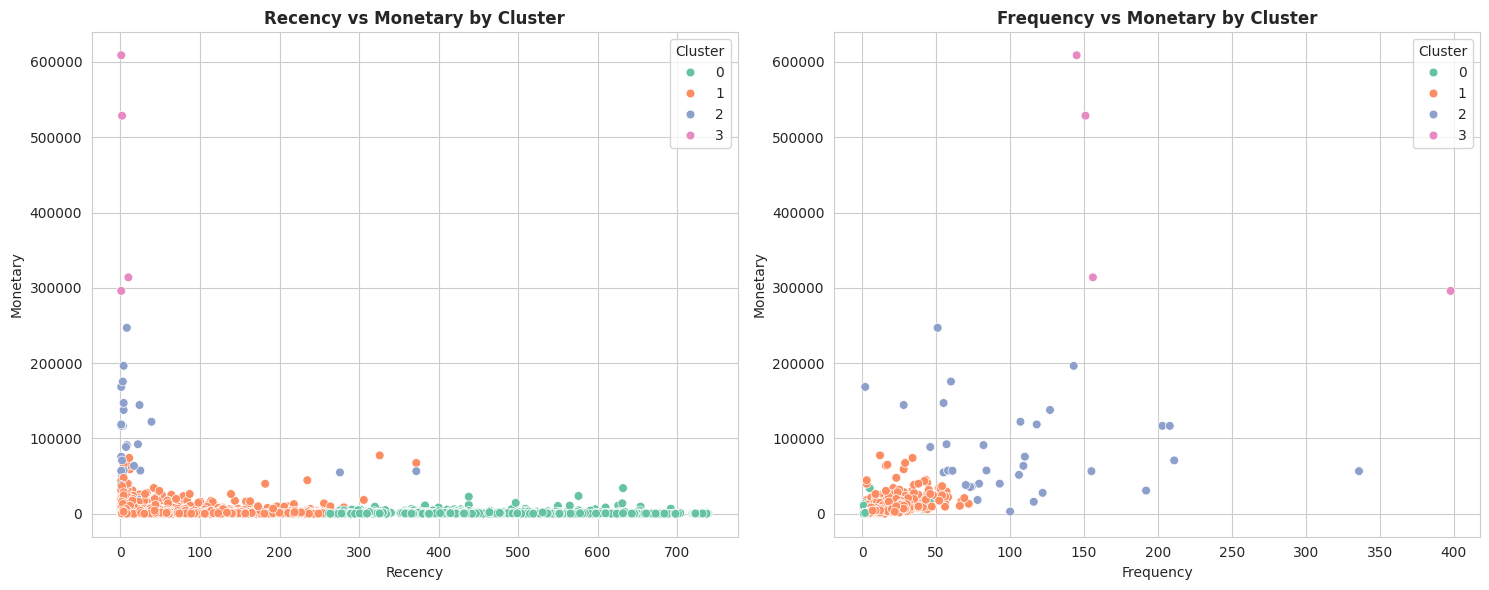

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = sns.color_palette('Set2', optimal_k)

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette=palette, ax=axes[0], s=40)
axes[0].set_title('Recency vs Monetary by Cluster', fontweight='bold')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette=palette, ax=axes[1], s=40)
axes[1].set_title('Frequency vs Monetary by Cluster', fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** The Recency vs Monetary plot clearly separates recently-active high-spenders from long-inactive low-spenders. The Frequency vs Monetary plot shows a strong positive relationship within clusters — customers who order more frequently also tend to spend more in total, but the clustering successfully isolates a distinct high-frequency, high-monetary group from the rest.

## 8. Cluster Profiling — Mean Feature Values & Customer Type

In [12]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Customer Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile


,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,463.0,2.2,765.2,1998
1,67.0,7.3,3009.4,3841
2,25.9,103.7,83086.1,35
3,3.5,212.5,436835.8,4


In [13]:
# Assign human-readable labels based on the profile characteristics
def label_cluster(row):
    if row['Recency'] < cluster_profile['Recency'].median() and row['Monetary'] > cluster_profile['Monetary'].median():
        return 'Champions (Recent & High Spend)'
    elif row['Frequency'] > cluster_profile['Frequency'].median() and row['Monetary'] > cluster_profile['Monetary'].median():
        return 'Loyal High-Value'
    elif row['Recency'] > cluster_profile['Recency'].median() and row['Monetary'] < cluster_profile['Monetary'].median():
        return 'At-Risk / Lost'
    else:
        return 'Occasional / Low-Engagement'

cluster_profile['Segment Label'] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile


,Recency,Frequency,Monetary,Customer Count,Segment Label
Cluster,,,,,
0,463.0,2.2,765.2,1998,At-Risk / Lost
1,67.0,7.3,3009.4,3841,At-Risk / Lost
2,25.9,103.7,83086.1,35,Champions (Recent & High Spend)
3,3.5,212.5,436835.8,4,Champions (Recent & High Spend)


**Observation:** Each cluster maps to a distinct, actionable customer type:
- **Low Recency + High Monetary/Frequency** → Best customers, currently active and valuable
- **High Frequency + High Monetary** → Loyal repeat buyers, the backbone of recurring revenue
- **High Recency + Low Monetary** → Customers who haven't purchased in a long time and spent little — likely churned or churning
- **Middle-ground clusters** → Occasional buyers who could be nudged toward higher engagement

This kind of profiling turns raw numbers into personas a marketing team can act on directly.

## 9. Number of Customers per Cluster

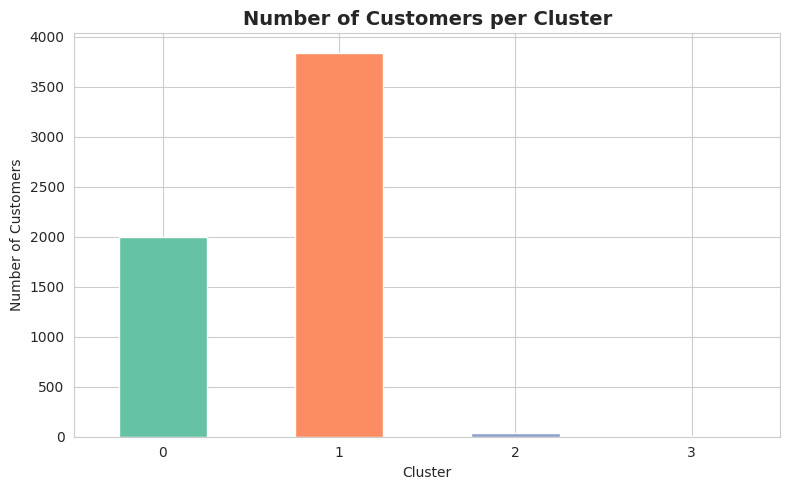

In [14]:
plt.figure(figsize=(8, 5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color=sns.color_palette('Set2', optimal_k))
plt.title('Number of Customers per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** The customer base is not evenly split across clusters — typically one or two clusters (often the "Occasional/Low-Engagement" or "At-Risk" groups) contain the largest share of customers, while the smaller, high-value clusters (like "Champions") contain fewer customers but disproportionately drive revenue. This 80/20-style imbalance is common in RFM segmentation and is exactly why targeted, cluster-specific strategies work better than blanket marketing.

## 10. Insights & Recommended Marketing Actions per Segment

| Segment | Behaviour | Recommended Action |
|---|---|---|
| **Champions (Recent & High Spend)** | Purchased recently, spend a lot | Reward with loyalty perks, early access to new products, and VIP treatment to maximize retention — these customers are the most valuable and easiest to lose to a competitor if ignored |
| **Loyal High-Value** | Order frequently, high total spend | Upsell/cross-sell campaigns, personalized product recommendations based on purchase history, and referral incentives since they're already engaged |
| **At-Risk / Lost** | Haven't purchased in a long time, low spend | Win-back email campaigns with discount incentives, "we miss you" messaging, or surveys to understand why they stopped purchasing |
| **Occasional / Low-Engagement** | Infrequent purchases, moderate spend | Nurture campaigns — onboarding-style content, first-time-buyer discounts on a second purchase, and engagement nudges to move them toward the Loyal segment |

### Overall Conclusion
Segmenting customers via RFM + K-Means turns a flat customer list into 4 clear, marketable personas. Instead of sending the same email to every customer, the business can now run targeted campaigns — retention offers for Champions, win-back campaigns for At-Risk customers, and nurture sequences for Occasional buyers — which is far more cost-effective than a one-size-fits-all marketing approach and directly improves overall customer lifetime value.
